# Spam Detection using Logistic Regression

Confusion Matrix:  [[4991    0]
 [   0 5009]]
Accuracy Score:  1.0
Precision Score:  1.0
Recall Score:  1.0
F1 Score:  1.0


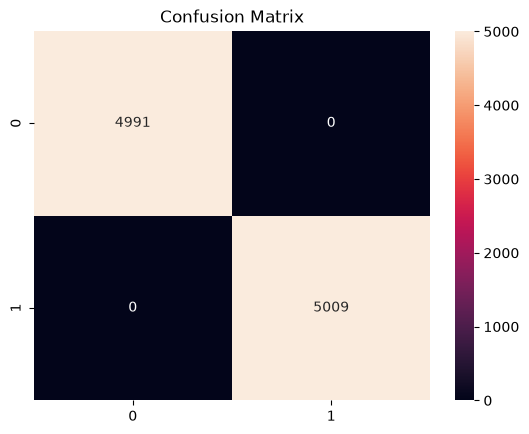

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

data = pd.read_csv('spam_email_dataset.csv')

data['text'] = (
    data['sender'].astype(str) + ' ' +
    data['subject'].astype(str) + ' ' +
    data['email_text'].astype(str)
)

X = data['text']
y = data['label']

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

confusion = confusion_matrix(y_test, y_pred)
print('Confusion Matrix: ',confusion)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score: ',accuracy)

precision = precision_score(y_test, y_pred, pos_label = 'Spam')
print('Precision Score: ',precision)

recall = recall_score(y_test, y_pred, pos_label = 'Spam')
print('Recall Score: ',recall)

f1 = f1_score(y_test, y_pred, pos_label = 'Spam')
print('F1 Score: ',f1)

sns.heatmap(confusion, annot = True, fmt = 'd')
plt.title('Confusion Matrix')
plt.show()